In [ ]:
# GA distance calculation

dist = [
    [0,10,15,25],
    [10,0,35,20],
    [15,35,0,30],
    [25,20,30,0]
]

ga_route = [0,1,3,2]

def ga_distance(route):
    total = 0
    for i in range(len(route)-1):
        total += dist[route[i]][route[i+1]]
    total += dist[route[-1]][route[0]]
    return total

print("GA Path:", ga_route + [ga_route[0]])
print("GA Distance:", ga_distance(ga_route))

GA Path: [0, 1, 3, 2, 0]
GA Distance: 75


In [ ]:
# ACO distance calculation

import numpy as np

dist = np.array([
    [0,10,15,25],
    [10,0,35,20],
    [15,35,0,30],
    [25,20,30,0]
])

# Example ACO route: A → D → C → B
aco_route = [0,3,2,1]

def aco_distance(route):
    total = 0
    for i in range(len(route)-1):
        total += dist[route[i]][route[i+1]]
    total += dist[route[-1]][route[0]]
    return total

print("ACO Path:", aco_route + [aco_route[0]])
print("ACO Distance:", aco_distance(aco_route))

ACO Path: [0, 3, 2, 1, 0]
ACO Distance: 100


In [ ]:
def calculate_aco_distance(route, dist):
    total = 0
    for i in range(len(route) - 1):
        total += dist[route[i]][route[i+1]]

    total += dist[route[-1]][route[0]]
    return total
aco_route = best_aco
print("ACO Route:", aco_route + [aco_route[0]])
print("ACO Distance:", calculate_aco_distance(aco_route, dist))

ACO Route: [1, np.int64(5), np.int64(2), np.int64(3), np.int64(4), np.int64(0), 1]
ACO Distance: 15.373182497877814


In [ ]:
import random
import numpy as np

dist = np.array([[0,10,15,20],
                 [10,0,35,25],
                 [15,35,0,30],
                 [20,25,30,0]])

n = 4
pheromone = np.ones((n,n))
alpha, beta, rho = 1, 2, 0.5

def route_length(route):
    return sum(dist[route[i]][route[i+1]] for i in range(n-1)) + dist[route[-1]][route[0]]

best_route = None
best_length = float('inf')

for _ in range(50):
    all_routes = []

    for _ in range(5):
        route = [0]
        while len(route) < n:
            i = route[-1]
            probs = []
            for j in range(n):
                if j not in route:
                    probs.append((pheromone[i][j]**alpha) * ((1/dist[i][j])**beta))
                else:
                    probs.append(0)
            probs = np.array(probs)
            probs = probs / probs.sum()
            next_city = np.random.choice(range(n), p=probs)
            route.append(next_city)

        all_routes.append(route)
        length = route_length(route)

        if length < best_length:
            best_length = length
            best_route = route

    pheromone *= (1 - rho)
    for route in all_routes:
        length = route_length(route)
        for i in range(n-1):
            pheromone[route[i]][route[i+1]] += 1/length

print("Best Route:", best_route)
print("Distance:", best_length)

Best Route: [0, np.int64(1), np.int64(3), np.int64(2)]
Distance: 80


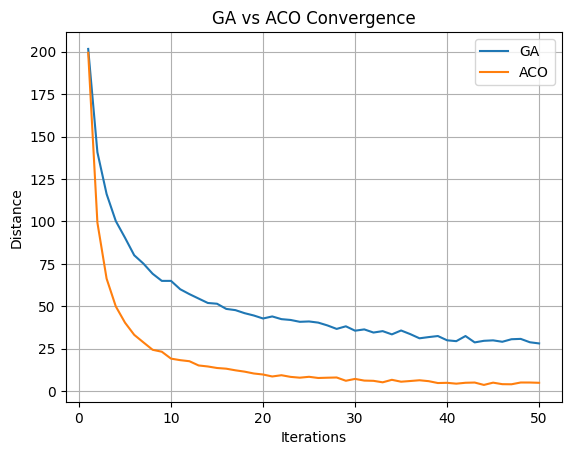

GA Path: [5, 4, 0, 1, 2, 3, 5]
ACO Path: [1, np.int64(5), np.int64(2), np.int64(3), np.int64(4), np.int64(0), 1]


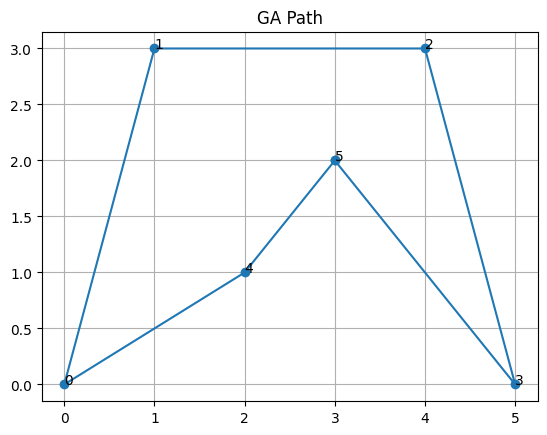

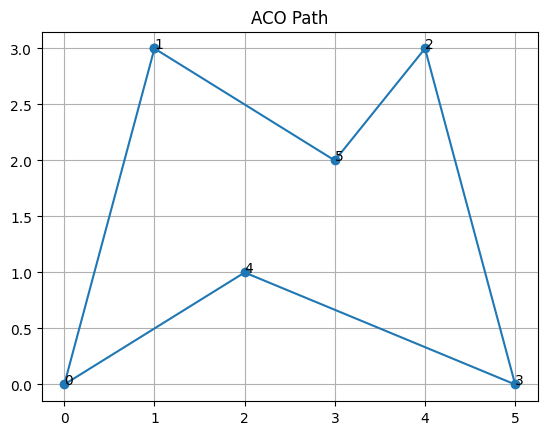

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
coords = np.array([
    [0,0],[1,3],[4,3],[5,0],[2,1],[3,2]
])
n = len(coords)
dist = np.zeros((n,n))
for i in range(n):
    for j in range(n):
        dist[i][j] = np.linalg.norm(coords[i]-coords[j])

cities = list(range(n))
def fitness(route):
    return sum(dist[route[i]][route[i+1]] for i in range(n-1)) + dist[route[-1]][route[0]]
def create_route():
    r = cities[:]
    random.shuffle(r)
    return r
def crossover(p1, p2):
    start, end = sorted(random.sample(range(n), 2))
    child = [-1]*n
    child[start:end] = p1[start:end]
    fill = [c for c in p2 if c not in child]
    j = 0
    for i in range(n):
        if child[i] == -1:
            child[i] = fill[j]
            j += 1
    return child
def mutate(route):
    if random.random() < 0.7:
        i, j = random.sample(range(n), 2)
        route[i], route[j] = route[j], route[i]
    return route

population = [create_route() for _ in range(6)]

for _ in range(20):
    population = sorted(population, key=fitness)
    new_pop = population[:2]
    while len(new_pop) < 6:
        child = crossover(population[0], population[1])
        new_pop.append(mutate(child))
    population = new_pop

best_ga = min(population, key=fitness)
pheromone = np.ones((n,n))
alpha, beta, rho = 1, 1, 0.3
def route_length(route):
    return fitness(route)

best_aco = None
best_len = float('inf')

for _ in range(20):
    all_routes = []
    for _ in range(6):
        route = [random.randint(0,n-1)]
        while len(route) < n:
            i = route[-1]
            probs = []
            for j in range(n):
                if j not in route:
                    probs.append((pheromone[i][j]**alpha) * ((1/(dist[i][j]+1e-6))**beta))
                else:
                    probs.append(0)

            probs = np.array(probs)
            probs = probs / probs.sum()
            route.append(np.random.choice(range(n), p=probs))

        all_routes.append(route)
        length = route_length(route)

        if length < best_len:
            best_len = length
            best_aco = route

    pheromone *= (1 - rho)
def plot_route(route, title):
    route = route + [route[0]]
    x = [coords[i][0] for i in route]
    y = [coords[i][1] for i in route]

    plt.figure()
    plt.plot(x, y, marker='o')
    for i,(xi,yi) in enumerate(coords):
        plt.text(xi, yi, str(i))
    plt.title(title)
    plt.grid()
    plt.show()
print("GA Path:", best_ga + [best_ga[0]])
print("ACO Path:", best_aco + [best_aco[0]])
plot_route(best_ga, "GA Path")
plot_route(best_aco, "ACO Path")

In [ ]:
import random

# Distance matrix
dist = [
    [0, 10, 15, 25],
    [10, 0, 35, 20],
    [15, 35, 0, 30],
    [25, 20, 30, 0]
]

# Sample routes (parents)
parent1 = [0, 1, 3, 2]
parent2 = [0, 2, 1, 3]

# Crossover function (Order Crossover for TSP)
def crossover(p1, p2):
    size = len(p1)
    start, end = sorted(random.sample(range(1, size), 2))  # exclude first city
    child = [None]*size
    # Copy a slice from first parent
    child[start:end] = p1[start:end]

    # Fill remaining from second parent in order
    fill_pos = end
    for city in p2[1:]:
        if city not in child:
            if fill_pos >= size:
                fill_pos = 1
            child[fill_pos] = city
            fill_pos += 1
    child[0] = p1[0]  # start city remains
    return child

# Mutation function (Swap Mutation)
def mutate(route, mutation_rate=0.2):
    route = route.copy()
    if random.random() < mutation_rate:
        i, j = random.sample(range(1, len(route)), 2)  # don't swap start city
        route[i], route[j] = route[j], route[i]
    return route

# Example
child = crossover(parent1, parent2)
mutated_child = mutate(child)

print("Parent 1:", parent1)
print("Parent 2:", parent2)
print("Child after Crossover:", child)
print("Child after Mutation:", mutated_child)

Parent 1: [0, 1, 3, 2]
Parent 2: [0, 2, 1, 3]
Child after Crossover: [0, 1, 3, 2]
Child after Mutation: [0, 1, 3, 2]


In [ ]:
import random

# Distance matrix
dist = [
    [0, 10, 15, 25],
    [10, 0, 35, 20],
    [15, 35, 0, 30],
    [25, 20, 30, 0]
]

num_cities = 4
pop_size = 6
generations = 10
mutation_rate = 0.2

# Calculate total distance of a route
def route_distance(route):
    total = 0
    for i in range(len(route)-1):
        total += dist[route[i]][route[i+1]]
    total += dist[route[-1]][route[0]]
    return total

# Order Crossover (OX) for TSP
def crossover(parent1, parent2):
    size = len(parent1)
    start, end = sorted(random.sample(range(1, size), 2))  # exclude first city
    child = [None]*size
    # Copy slice from parent1
    child[start:end] = parent1[start:end]
    # Fill remaining from parent2 in order
    fill_pos = end
    for city in parent2[1:]:
        if city not in child:
            if fill_pos >= size:
                fill_pos = 1
            child[fill_pos] = city
            fill_pos += 1
    child[0] = parent1[0]  # start city fixed
    return child

# Swap Mutation
def mutate(route, mutation_rate=0.2):
    route = route.copy()
    if random.random() < mutation_rate:
        i, j = random.sample(range(1, len(route)), 2)
        route[i], route[j] = route[j], route[i]
    return route

# Tournament Selection
def tournament_selection(population, k=3):
    selected = random.sample(population, k)
    selected.sort(key=lambda r: route_distance(r))
    return selected[0]

# Create initial population
def create_population(pop_size, num_cities):
    population = []
    for _ in range(pop_size):
        route = list(range(num_cities))
        random.shuffle(route[1:])  # keep start city fixed
        population.append(route)
    return population

# GA main loop
population = create_population(pop_size, num_cities)

print("Initial Population:")
for route in population:
    print(route, "Distance:", route_distance(route))

for gen in range(generations):
    new_population = []
    for _ in range(pop_size):
        parent1 = tournament_selection(population)
        parent2 = tournament_selection(population)
        child = crossover(parent1, parent2)
        child = mutate(child, mutation_rate)
        new_population.append(child)
    population = new_population
    best_route = min(population, key=route_distance)
    print(f"\nGeneration {gen+1}: Best Route: {best_route + [best_route[0]]} Distance: {route_distance(best_route)}")

Initial Population:
[0, 1, 2, 3] Distance: 100
[0, 1, 2, 3] Distance: 100
[0, 1, 2, 3] Distance: 100
[0, 1, 2, 3] Distance: 100
[0, 1, 2, 3] Distance: 100
[0, 1, 2, 3] Distance: 100

Generation 1: Best Route: [0, 1, 2, 3, 0] Distance: 100

Generation 2: Best Route: [0, 3, 1, 2, 0] Distance: 95

Generation 3: Best Route: [0, 3, 1, 2, 0] Distance: 95

Generation 4: Best Route: [0, 1, 3, 2, 0] Distance: 75

Generation 5: Best Route: [0, 1, 3, 2, 0] Distance: 75

Generation 6: Best Route: [0, 2, 3, 1, 0] Distance: 75

Generation 7: Best Route: [0, 2, 3, 1, 0] Distance: 75

Generation 8: Best Route: [0, 2, 3, 1, 0] Distance: 75

Generation 9: Best Route: [0, 2, 3, 1, 0] Distance: 75

Generation 10: Best Route: [0, 1, 3, 2, 0] Distance: 75


In [ ]:
import numpy as np

# Distance matrix
dist = np.array([
    [0, 10, 15, 25],
    [10, 0, 35, 20],
    [15, 35, 0, 30],
    [25, 20, 30, 0]
])

num_cities = len(dist)
num_ants = 3
alpha = 1     # pheromone importance
beta = 5      # heuristic importance
rho = 0.5     # pheromone evaporation
Q = 100       # pheromone deposit factor
iterations = 5

# Initial pheromone matrix
tau = np.ones((num_cities, num_cities))

# Heuristic information (1/distance)
eta = 1 / (dist + np.diag([1e10]*num_cities))  # avoid div by zero

# Step 1: Ant constructs a path
def choose_next_city(current, visited, tau, eta, alpha, beta):
    probs = []
    for j in range(num_cities):
        if j in visited:
            probs.append(0)
        else:
            probs.append((tau[current][j]**alpha) * (eta[current][j]**beta))
    probs = np.array(probs)
    total = probs.sum()
    if total == 0:
        return random.choice([c for c in range(num_cities) if c not in visited])
    probs = probs / total
    next_city = np.random.choice(range(num_cities), p=probs)
    return next_city

# Step 2: Build paths for all ants
def construct_paths(tau, eta):
    paths = []
    distances = []
    for ant in range(num_ants):
        path = [0]  # start from city 0
        while len(path) < num_cities:
            next_city = choose_next_city(path[-1], path, tau, eta, alpha, beta)
            path.append(next_city)
        distance = sum([dist[path[i]][path[i+1]] for i in range(num_cities-1)]) + dist[path[-1]][path[0]]
        paths.append(path)
        distances.append(distance)
        print(f"Ant {ant+1} path: {path + [path[0]]} Distance: {distance}")
    return paths, distances

# Step 3: Update pheromone
def update_pheromone(tau, paths, distances):
    # Evaporation
    tau *= (1 - rho)
    # Deposit pheromone
    for path, distance in zip(paths, distances):
        for i in range(num_cities):
            from_city = path[i]
            to_city = path[(i+1)%num_cities]
            tau[from_city][to_city] += Q / distance
            tau[to_city][from_city] += Q / distance
    print("Updated Pheromone Matrix:\n", np.round(tau, 2))
    return tau

# Run ACO
best_distance = float('inf')
best_path = None

for it in range(iterations):
    print(f"\n=== Iteration {it+1} ===")
    paths, distances = construct_paths(tau, eta)
    tau = update_pheromone(tau, paths, distances)
    min_dist = min(distances)
    if min_dist < best_distance:
        best_distance = min_dist
        best_path = paths[distances.index(min_dist)]

print(f"\nBest Path Found: {best_path + [best_path[0]]} Distance: {best_distance}")


=== Iteration 1 ===
Ant 1 path: [0, np.int64(1), np.int64(3), np.int64(2), 0] Distance: 75
Ant 2 path: [0, np.int64(1), np.int64(3), np.int64(2), 0] Distance: 75
Ant 3 path: [0, np.int64(1), np.int64(3), np.int64(2), 0] Distance: 75
Updated Pheromone Matrix:
 [[0.5 4.5 4.5 0.5]
 [4.5 0.5 0.5 4.5]
 [4.5 0.5 0.5 4.5]
 [0.5 4.5 4.5 0.5]]

=== Iteration 2 ===
Ant 1 path: [0, np.int64(1), np.int64(3), np.int64(2), 0] Distance: 75
Ant 2 path: [0, np.int64(1), np.int64(3), np.int64(2), 0] Distance: 75
Ant 3 path: [0, np.int64(1), np.int64(3), np.int64(2), 0] Distance: 75
Updated Pheromone Matrix:
 [[0.25 6.25 6.25 0.25]
 [6.25 0.25 0.25 6.25]
 [6.25 0.25 0.25 6.25]
 [0.25 6.25 6.25 0.25]]

=== Iteration 3 ===
Ant 1 path: [0, np.int64(1), np.int64(3), np.int64(2), 0] Distance: 75
Ant 2 path: [0, np.int64(1), np.int64(3), np.int64(2), 0] Distance: 75
Ant 3 path: [0, np.int64(1), np.int64(3), np.int64(2), 0] Distance: 75
Updated Pheromone Matrix:
 [[0.12 7.12 7.12 0.12]
 [7.12 0.12 0.12 7.12]
 